### Problem 2: Building a Random Forest from Scratch

In this problem you will implement the core logic of a random forest by hand, then verify your results against sklearn. This is the ensemble analog of the from-scratch neural network in Problem 2 of the Module 5 homework.

Use the two moons dataset. Split into 70% train / 30 % test with random_state = 0. 

(a). $\bf{Bootstrap \: sampling}$. Write a function that draws a bootstrap of size N from a dataset of size N (sampling with replacement). Generate 5 bootstrap samples from the training set. For each, report the fraction of unique training points included. Verify that this is close to 1-1/e $\approx$ 63.2%.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

RNG = np.random.default_rng(0)

x, y = make_moons(n_samples=300, noise=0.3, random_state=42)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [3]:
def bootstrap_sample(X, y, rng):
    n = len(y)
    idx = rng.choice(n, size=n, replace=True) # pick n indices from 0 to n-1
    return X[idx], y[idx], idx # create dataset

print("Part (a): Bootstrap sampling:")

# Generate 5 bootstrap samples of size N
for b in range(5):
    X_boot, y_boot, idx = bootstrap_sample(x_train, y_train, RNG)
    frac_unique = len(np.unique(idx)) / len(y_train) # divide distinct sampled indices by total # of training points
    print(f"Sample {b+1}: {frac_unique:.3f} unique points")

print(f"Verification: ~{1 - 1/np.e:.3f}")

Part (a): Bootstrap sampling:
Sample 1: 0.662 unique points
Sample 2: 0.619 unique points
Sample 3: 0.638 unique points
Sample 4: 0.624 unique points
Sample 5: 0.643 unique points
Verification: ~0.632


(b). $\bf{Train \: individual \: trees}$. Train a DecisionTreeClassifier on each of the 5 bootstrap samples. Report the test accuracy of each individual tree.

In [4]:
print("\nPart (b): Individual trees")

trees = [] # to store each trained model 
tree_accs = [] # to store each tree's test accuracy

for b in range(5):
    x_boot, y_boot, _ = bootstrap_sample(x_train, y_train, RNG)

    tree = DecisionTreeClassifier(
        max_depth=None,
        max_features='sqrt', # make each tree consider only a random subset of features at every split
        random_state=b
    )
    tree.fit(x_boot, y_boot)

    acc = tree.score(x_test, y_test)

    trees.append(tree)
    tree_accs.append(acc)

    print(f"Tree {b}: test accuracy = {acc:.3f}")


Part (b): Individual trees
Tree 0: test accuracy = 0.867
Tree 1: test accuracy = 0.789
Tree 2: test accuracy = 0.822
Tree 3: test accuracy = 0.867
Tree 4: test accuracy = 0.878


(c). $\bf{Majority \: vote.}$ For each test sample, collect the predictions of all 5 trees and take the majority vote. Report the ensemble's test accuracy. Is it better than the average individual tree accuracy? Is it better than the best individual tree?


In [5]:
print("\nPart (c): Majority vote")

all_preds = np.array([tree.predict(x_test) for tree in trees])

majority_vote = (np.mean(all_preds, axis=0) >= 0.5).astype(int)
ensemble_acc = accuracy_score(y_test, majority_vote)
individual_accs = [tree.score(x_test, y_test) for tree in trees]

print(f'Individual tree accuracies: {["{:.1%}".format(a) for a in individual_accs]}')
print(f'Mean individual accuracy:   {np.mean(individual_accs):.1%}')
print(f'Best individual accuracy:   {np.max(individual_accs):.1%}')
print(f'Ensemble (majority vote):   {ensemble_acc:.1%}')

print("\nConclusion:")
print("Better than average tree?", ensemble_acc > np.mean(individual_accs))
print("Better than best tree?", ensemble_acc > np.max(individual_accs))


Part (c): Majority vote
Individual tree accuracies: ['86.7%', '78.9%', '82.2%', '86.7%', '87.8%']
Mean individual accuracy:   84.4%
Best individual accuracy:   87.8%
Ensemble (majority vote):   88.9%

Conclusion:
Better than average tree? True
Better than best tree? True


(d). $\bf{Scaling \: up.}$ Repeat parts (a) - (c) for B = 1, 5, 20, 25, 50, 100, 200 trees. Plot the ensemble test accuracy vs. B. On the same plot, show the accuracy of sklearn.ensemble.RandomForestClassifier with the same number of estimators. Do they agree?

In [ ]:
print("\nPart (d): Scaling up")

B_vals = [1, 5, 10, 25, 50, 100, 200]

og_accs = []
sk_accs = []

for B in B_vals:
    trees = []
    predictions = []

    # Training B bootstrap trees
    for b in range(B):
        x_boot, y_boot, _ = bootstrap_sample(x_train, y_train, RNG)

        tree = DecisionTreeClassifier(
            max_depth=None,
            max_features='sqrt',
            random_state=b
        )
        tree.fit(x_boot, y_boot)

        trees.append(tree)
        predictions.append(tree.predict(x_test))

    predictions = np.array(predictions)

    ensemble_pred = (np.mean(predictions, axis=0) >= 0.5).astype(int)
    ensemble_acc = np.mean(ensemble_pred == y_test)
    og_accs.append(ensemble_acc)

    # sklearn random forest classifier
    rf = RandomForestClassifier(
        n_estimators=B,
        max_depth=None,
        max_features='sqrt',
        bootstrap=True,
        random_state=0
    )
    rf.fit(x_train, y_train)

    rf_acc = rf.score(x_test, y_test)
    sk_accs.append(rf_acc)

    print(f"B = {B:3d} | scratch = {ensemble_acc:.3f} | sklearn = {rf_acc:.3f}")


Part (d): Scaling up
B =   1 | scratch = 0.822 | sklearn = 0.856
B =   5 | scratch = 0.878 | sklearn = 0.844
B =  10 | scratch = 0.900 | sklearn = 0.844
B =  25 | scratch = 0.867 | sklearn = 0.889
B =  50 | scratch = 0.856 | sklearn = 0.867
B = 100 | scratch = 0.844 | sklearn = 0.867
B = 200 | scratch = 0.878 | sklearn = 0.867


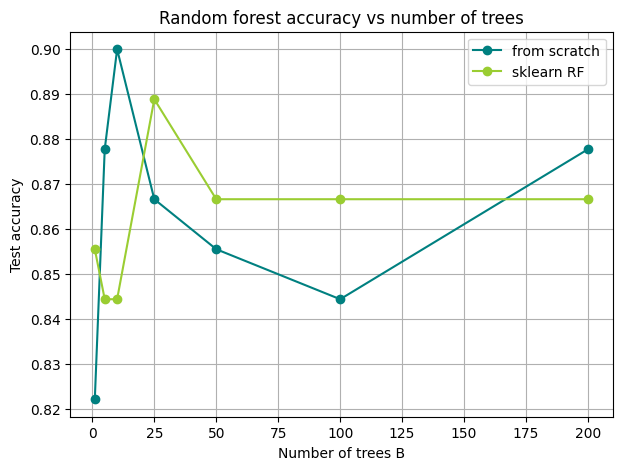

In [16]:
import matplotlib.colors as mcolors

plt.figure(figsize=(7, 5))
plt.plot(B_vals, og_accs, marker='o', color= 'teal', label='from scratch')
plt.plot(B_vals, sk_accs, marker='o', color= 'yellowgreen', label='sklearn RF')

plt.xlabel("Number of trees B")
plt.ylabel("Test accuracy")
plt.title("Random forest accuracy vs number of trees")
plt.legend()
plt.grid(True)
plt.show()